In [1]:
import pandas as pd
df = pd.read_csv('Invistico_Airline.csv')
print("Data loaded successfully!")
print(f"Dataset Shape: {df.shape}")
df.head()

Data loaded successfully!
Dataset Shape: (129880, 22)


,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0


In [2]:
median_delay = df['Arrival Delay in Minutes'].median()
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(median_delay)
print("Missing values cleaned!")

Missing values cleaned!


In [3]:
X = df.drop(columns=['satisfaction'])
y = df['satisfaction'].apply(lambda x: 1 if x == 'satisfied' else 0)
print("Features and target separated!")

Features and target separated!


In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Trian and test sets created!")

Trian and test sets created!


In [5]:
import pandas as pd
X_train_enc = pd.get_dummies(X_train, drop_first=True)
X_test_enc = pd.get_dummies(X_test, drop_first=True)
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join='left', axis=1, fill_value=0)
print("Categorical encoding complete!")

Categorical encoding complete!


In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
dt_base = DecisionTreeClassifier(random_state=42)
param_grid = {'max_depth':[3, 5, 10], 'min_samples_leaf':[1, 2, 5]}
grid = GridSearchCV(dt_base, param_grid, cv=3, scoring='f1', n_jobs=-1)
grid.fit(X_train_enc, y_train)
print(f"Grid Search complete! Best parameters: {grid.best_params_}")

Grid Search complete! Best parameters: {'max_depth': 10, 'min_samples_leaf': 1}


In [13]:
from sklearn.metrics import classification_report, f1_score
best_dt = grid.best_estimator_
y_pred_dt = best_dt.predict(X_test_enc)
print(f"F1-Score for 'Satisfied' Class: {f1_score(y_test, y_pred_dt):.4f}\n")
print(classification_report(y_test, y_pred_dt))

F1-Score for 'Satisfied' Class: 0.9275

              precision    recall  f1-score   support

           0       0.90      0.93      0.92     11759
           1       0.94      0.91      0.93     14217

    accuracy                           0.92     25976
   macro avg       0.92      0.92      0.92     25976
weighted avg       0.92      0.92      0.92     25976



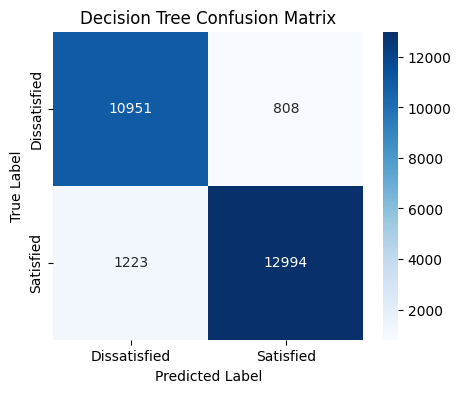

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Dissatisfied', 'Satisfied'],yticklabels=['Dissatisfied', 'Satisfied'])
plt.title('Decision Tree Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

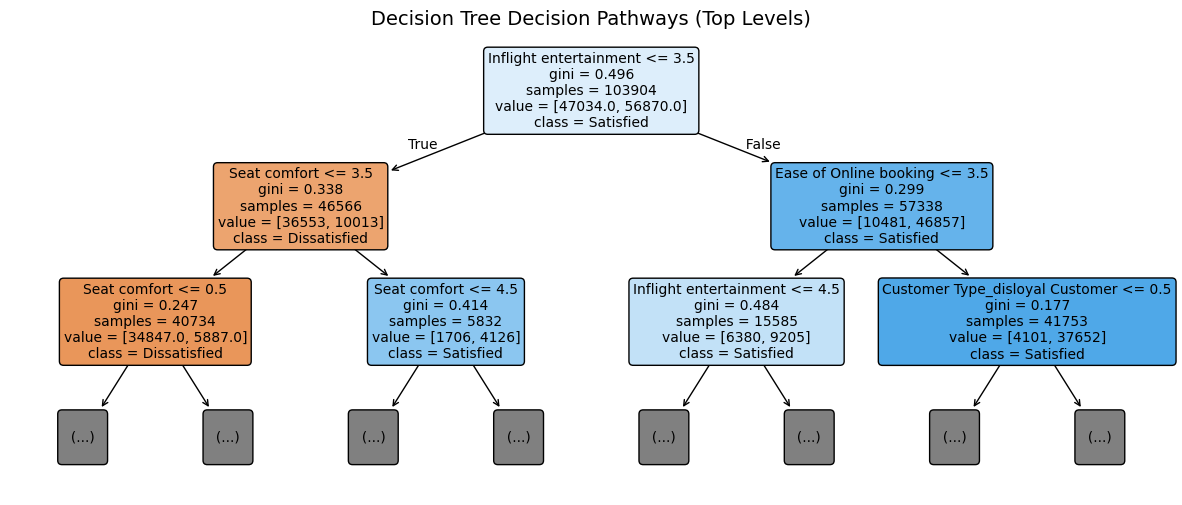

In [15]:
from sklearn.tree import plot_tree
plt.figure(figsize=(15,6))
plot_tree(best_dt, max_depth=2, feature_names=X_train_enc.columns.tolist(), class_names=['Dissatisfied', 'Satisfied'], filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree Decision Pathways (Top Levels)", fontsize=14)
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_8172\2381856515.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')


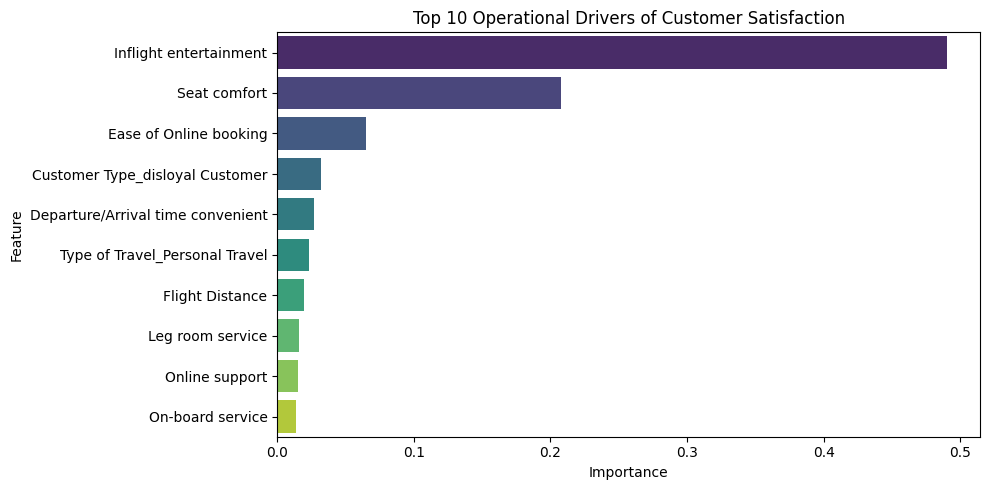

In [16]:
import pandas as pd
importances = best_dt.feature_importances_
feat_df = pd.DataFrame({'Feature': X_train_enc.columns, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')
plt.title('Top 10 Operational Drivers of Customer Satisfaction')
plt.tight_layout()
plt.show()

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled = scaler.transform(X_test_enc)
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
print(f"Logistic Regression F1-Score: {f1_score(y_test, y_pred_lr):.4f}\n")
print(classification_report(y_test, y_pred_lr))

Logistic Regression F1-Score: 0.8436

              precision    recall  f1-score   support

           0       0.81      0.81      0.81     11759
           1       0.84      0.84      0.84     14217

    accuracy                           0.83     25976
   macro avg       0.83      0.83      0.83     25976
weighted avg       0.83      0.83      0.83     25976



# project Evaluation Report: Airline Customer Satisfaction
## 1. Project Overview & Objective
This project analyzes pssenger survey data using Python and Scikit-learn to build an optimized Decision Tree Classifier.The objective is to accurately predict customer satisfaction and exract actionable operational insights to drive targeted service improvements for airline management.
---
## 2. Hyperparameter Tuning Strategy (Grid Search CV)
To build a model that generalizes well to unseen passenger data, we implemented 'GridSearchCV' with 3-fold cross-validation.
***'max_depth'**: Controls the vertical depth of the tree to mitigate overfitting on trianing noise.
***'min_samples_leaf**: Dictates the minimum number of passenger samples required to exist at a leaf node, ensuring stable statistical patterns rather than isolated data anomalies.
**Optimal Structure Validation:**
* 'max_depth': 10
* 'min_samples_leaf': 1
---
## 3. performance Evaluation Rationale
We utilize a **Confusion Matrix** and the **F1-Score** specifically for the 
"Satisfied" class to evaluate our classification performance.
* Relying solely on raw accuracy can mask model deficiencies.
* The F1-Score provides a harmonic mean of **Precision** (avoiding false alarms of satisfaction) and **Recall** (ensuring we don't miss genuinely dissatisfied customers), striking a business-critical balance for customer retention strategies.
---
## 5. Key Operational Drivers
The Decision Tree structural analysis ranks operational variables by their information gain(Feature importance).
Airline management should prioritize capital allocation toward these top drivers to maximize future survey scores:
1. **Inflight Entertainment**:The primary root differentiator of positive sentiment.
2. **Seat Confort**: The leading physical/ergonomic comfort driver.
3. **Ease of Online Booking**: The key digital touchpoint determining initial friction.
---
## 5. Strategic Business Comparison
|Metric / Dimension | Decision Tree Classifier | Logistic Regression |
| :--- | :--- | :--- |
| **Overall Accuracy** | **92.00%** (Superior) | **83.00%** (Sub-optimal) |
| **F1-Score(Satisfied)** | **0.9275** | **0.8436** |
| **Non-Linear Relationships** |
**Excellent.** Natively captures complex intaractions(e.g.,seat comfort matters exponentially more on long-haul flights).
| **Poor.** Assumes a strictly linear relationship unless complex manual engineering is performed. |
| **Business Actionability** | **High.** Outputs transparent, audible "If-Then" logic pathways easily understood by non-technical managers. |
**Moderate.** Outputs coefficients requiring mathematical transformation to drive business meaning. |
**Final Recommendation:** Airline management should deploy the 
**Decision Tree Model**. It yields a 9% absolute performance improvement and provides an audible flowchart structure that non-technical stakeholders can directly translate into operational policy updates.